最优解: -0.006248846965563715
最优能量: 3.904808839903485e-05


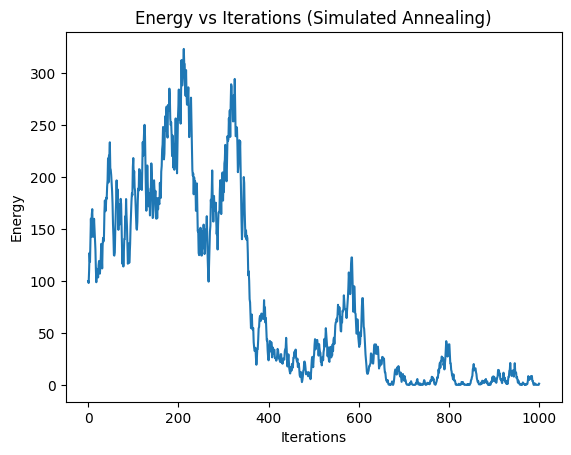

In [3]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

# 目标函数 f(x) = x^2
def objective_function(x):
    return x**2

# 模拟退火算法
def simulated_annealing(initial_solution, initial_temperature, cooling_rate, max_iterations):
    current_solution = initial_solution
    current_energy = objective_function(current_solution)
    temperature = initial_temperature
    best_solution = current_solution
    best_energy = current_energy

    energies = [current_energy]  # 用于记录能量的变化

    for iteration in range(max_iterations):
        # 生成一个扰动解
        new_solution = current_solution + random.uniform(-1, 1)
        new_energy = objective_function(new_solution)

        # 计算接受新解的概率
        if new_energy < current_energy:  # 如果新解更优，直接接受
            current_solution = new_solution
            current_energy = new_energy
        else:
            # 否则，根据温度和能量差决定是否接受
            acceptance_probability = math.exp((current_energy - new_energy) / temperature)
            if random.random() < acceptance_probability:
                current_solution = new_solution
                current_energy = new_energy

        # 更新最优解
        if current_energy < best_energy:
            best_solution = current_solution
            best_energy = current_energy

        # 降温
        temperature *= cooling_rate
        energies.append(current_energy)

    return best_solution, best_energy, energies

# 设置初始参数
initial_solution = 10  # 初始解
initial_temperature = 1000  # 初始温度
cooling_rate = 0.995  # 降温速率
max_iterations = 1000  # 最大迭代次数

# 调用模拟退火算法
best_solution, best_energy, energies = simulated_annealing(initial_solution, initial_temperature, cooling_rate, max_iterations)

# 输出结果
print("最优解:", best_solution)
print("最优能量:", best_energy)

# 绘制能量变化图
plt.plot(energies)
plt.title('Energy vs Iterations (Simulated Annealing)')
plt.xlabel('Iterations')
plt.ylabel('Energy')
plt.show()
